Key variables:

Jitter → frequency instability

Shimmer → amplitude instability

These relate directly to motor control of vocal folds

Load and inspect

In [1]:
import pandas as pd

df = pd.read_csv("data/2025_parkinsons.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          194 non-null    float64
 7   MDVP:PPQ          194 non-null    float64
 8   Jitter:DDP        194 non-null    float64
 9   MDVP:Shimmer      194 non-null    float64
 10  MDVP:Shimmer(dB)  194 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      193 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       194 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,194.000000,194.000000,194.000000,194.000000,194.000000,...,194.000000,195.000000,195.000000,193.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003317,0.003436,0.009930,0.029801,0.282979,...,0.046921,0.024847,21.885974,0.756477,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002972,0.002763,0.008925,0.018862,0.195115,...,0.030521,0.040418,4.425764,0.430325,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001665,0.001860,0.004982,0.016575,0.149500,...,0.024668,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002680,0.007455,0.023025,0.221000,...,0.038335,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003853,0.003938,0.011558,0.037992,0.350000,...,0.059478,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


Check for missing values

In [11]:
df.isnull().sum()
df.duplicated().sum()
df.isna().sum()
df = df.dropna()
#df = df.drop(columns=["name"])



Exploratory Data Analysis (EDA)

<Axes: xlabel='status', ylabel='MDVP:Jitter(%)'>

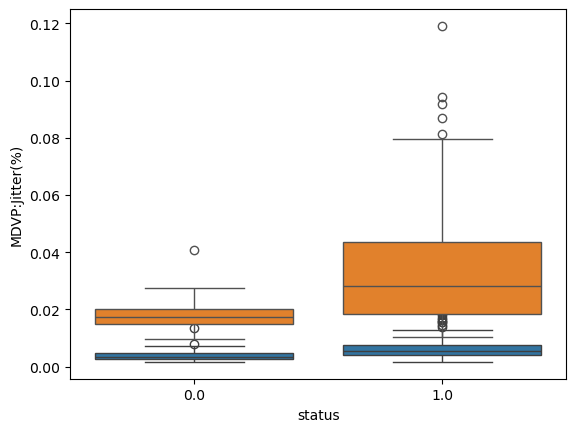

In [12]:
import seaborn as sns

sns.boxplot(x="status", y="MDVP:Jitter(%)", data=df)
sns.boxplot(x="status", y="MDVP:Shimmer", data=df)


Correlation analysis

<Axes: >

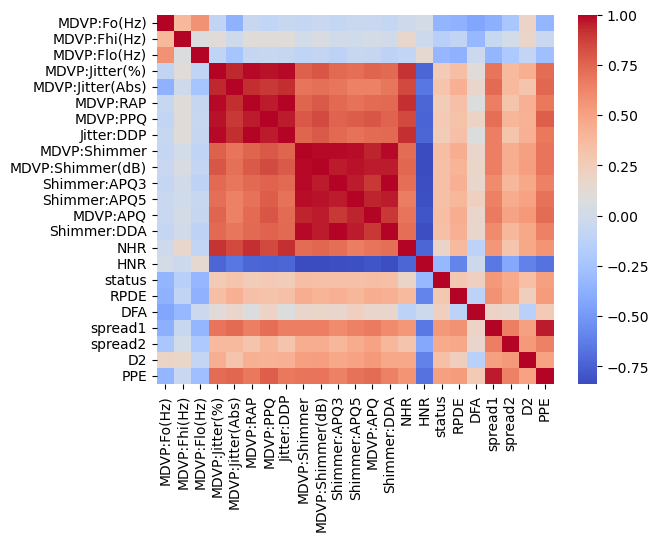

In [13]:
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm")


Statistical test

In [14]:
from scipy.stats import ttest_ind

healthy = df[df["status"] == 0]["MDVP:Jitter(%)"]
parkinson = df[df["status"] == 1]["MDVP:Jitter(%)"]

ttest_ind(healthy, parkinson)


TtestResult(statistic=np.float64(-3.6603361471384552), pvalue=np.float64(0.0003294212790428905), df=np.float64(183.0))

Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

X = df[["MDVP:Jitter(%)", "MDVP:Shimmer"]]
y = df["status"]

model = DecisionTreeClassifier(max_depth=2)
model.fit(X, y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Evaluate model

In [16]:
from sklearn.metrics import classification_report

y_pred = model.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         0.0       0.58      0.59      0.58        44
         1.0       0.87      0.87      0.87       141

    accuracy                           0.80       185
   macro avg       0.72      0.73      0.73       185
weighted avg       0.80      0.80      0.80       185



Visualize

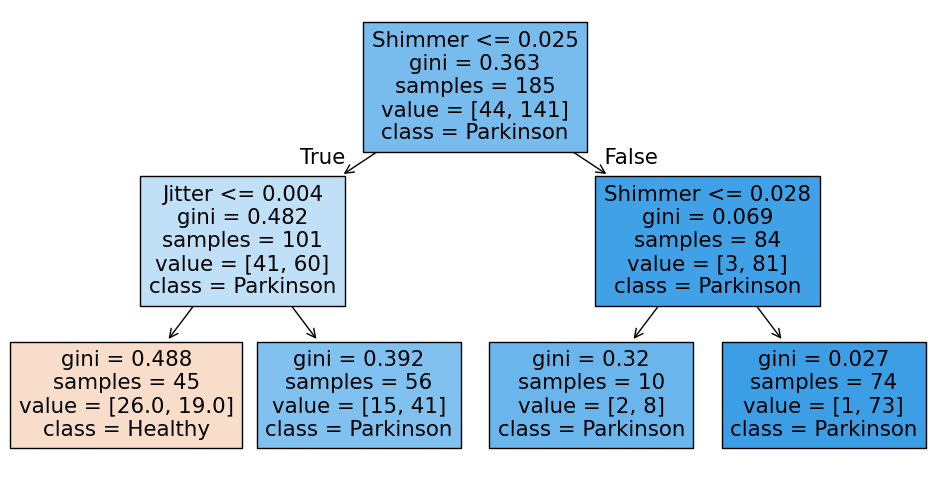

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plot_tree(
    model,
    feature_names=["Jitter", "Shimmer"],
    class_names=["Healthy", "Parkinson"],
    filled=True,
)
plt.show()

If Shimmer > 0.025 → almost always Parkinson
If Shimmer ≤ 0.025 → unclear → need Jitter

Shimmer > 0.028 → almost certain Parkinson (73 vs 1)


1. Shimmer is the dominant signal

A shimmer threshold around 0.025 separates most healthy and Parkinson cases.

Biological meaning:

Shimmer = amplitude instability
→ reflects poor control of vocal fold closure
→ linked to motor dysfunction in Parkinson’s


2. Jitter refines borderline cases

When shimmer is low, jitter helps distinguish between healthy and Parkinson patients.

Biological meaning:

Jitter = frequency instability
→ fine motor timing control


A decision tree classifier identified shimmer as the primary discriminative feature. A threshold at approximately 0.025 effectively separates most Parkinson’s patients from healthy individuals. For cases with lower shimmer values, jitter provides additional discriminatory power, suggesting that both amplitude and frequency instabilities contribute to the degradation of fine motor control in speech.